# **Liberías**

In [1]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 2.5 MB/s eta 0:00:00


In [2]:
#from mplsoccer import PyPizza
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

from sqlalchemy import create_engine, select
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker

import glob
import os

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

In [ ]:
#df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_TempActual_Jugadores.xlsx')
#df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_Historico_Jugadores.xlsx')

In [ ]:
#df_players = df.copy()
#hacer copia para no perder el original
#df_players = df.drop('Unnamed: 0', axis=1)
#df_players = df_players.drop_duplicates()

# **Lectura BBDD**

In [3]:
# Configuración de la conexión a PostgreSQL
usuario = "avnadmin"
contrasena = "AVNS_Snql1CSp1zYrJCH6cXE"
servidor = "my-database-pg-my-data22.f.aivencloud.com"
puerto = "13676"
base_datos = "my_wyscout"

# Crea la cadena de conexión
conexion_str = f'postgresql+psycopg2://{usuario}:{contrasena}@{servidor}:{puerto}/{base_datos}'
engine = create_engine(conexion_str)

In [18]:
s_sql = text("""
SELECT "Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica", "Edad", "Valor de mercado (Transfermarkt)", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90", "Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En prestamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %", "Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Posesión conquistada después de una entrada", "Tiros interceptados/90", "Interceptaciones/90", "Posesión conquistada después de una interceptación", "Faltas/90", "Tarjetas amarillas", "Tarjetas amarillas/90", "Tarjetas rojas", "Tarjetas rojas/90", "Acciones de ataque exitosas/90", "Goles/90", "Goles (excepto los penaltis)", "Goles, excepto los penaltis/90", "xG/90", "Goles de cabeza", "Goles de cabeza/90", "Remates", "Remates/90", "Tiros a la portería %", "Goles hechos %", "Asistencias/90", "Centros/90", "Precisión centros %", "Centros desde la banda izquierda/90", "Precisión centros desde la banda izquierda %", "Centros desde la banda derecha/90", "Precisión centros desde la banda derecha %", "Centros al área pequeña/90", "Regates/90", "Regates realizados %", "Duelos atacantes/90", "Duelos atacantes ganados %", "Toques en el área de penalti/90", "Carreras en progresión/90", "Aceleraciones/90", "Pases recibidos/90", "Pases largos recibidos/90", "Faltas recibidas/90", "Pases/90", "Precisión pases %", "Pases hacia adelante/90", "Precisión pases hacia adelante %", "Pases hacia atrás/90", "Precision pases hacia atrás %", "Pases laterales/90", "Precisión pases laterales %", "Pases cortos / medios/90", "Precisión pases cortos / medios %", "Pases largos/90", "Precisión pases largos %", "Longitud media pases, m", "Longitud media pases largos, m", "xA/90", "Asistencias/90.1", "Second assists/90", "Third assists/90", "Desmarques/90", "Precisión desmarques %", "Jugadas claves/90", "Pases en el último tercio/90", "Precisión pases en el último tercio %", "Pases al área de penalti/90", "Pases hacía el área pequeña %", "Pases en profundidad/90", "Precisión pases en profundidad %", "Ataque en profundidad/90", "Centros desde el último tercio/90", "Pases progresivos/90", "Precisión pases progresivos %", "Goles recibidos", "Goles recibidos/90", "Remates en contra", "Remates en contra/90", "Porterías imbatidas/90", "Paradas %", "xG en contra", "xG en contra/90", "Goles evitados", "Goles evitados/90", "Pases hacía atrás recibidos del arquero/90", "Salidas/90", "Duelos aéreos/90.1", "Tiros libres/90", "Tiros libres directos/90", "Tiros libres directos %", "Córneres/90", "Penaltis a favor", "Penaltis realizados %", "Competición", "Temporada", "Pais_Comp", "Flag", "Posición Principal", "Fecha_Actualizacion"
FROM jugadores j
union
SELECT "Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica", "Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90", "Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %", "Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Posesión conquistada después de una entrada", "Tiros interceptados/90", "Interceptaciones/90", "Posesión conquistada después de una interceptación", "Faltas/90", "Tarjetas amarillas", "Tarjetas amarillas/90", "Tarjetas rojas", "Tarjetas rojas/90", "Acciones de ataque exitosas/90", "Goles/90", "Goles (excepto los penaltis)", "Goles, excepto los penaltis/90", "xG/90", "Goles de cabeza", "Goles de cabeza/90", "Remates", "Remates/90", "Tiros a la portería %", "Goles hechos %", "Asistencias/90", "Centros/90", "Precisión centros %", "Centros desde la banda izquierda/90", "Precisión centros desde la banda izquierda %", "Centros desde la banda derecha/90", "Precisión centros desde la banda derecha %", "Centros al área pequeña/90", "Regates/90", "Regates realizados %", "Duelos atacantes/90", "Duelos atacantes ganados %", "Toques en el área de penalti/90", "Carreras en progresión/90", "Aceleraciones/90", "Pases recibidos/90", "Pases largos recibidos/90", "Faltas recibidas/90", "Pases/90", "Precisión pases %", "Pases hacia adelante/90", "Precisión pases hacia adelante %", "Pases hacia atrás/90", "Precision pases hacia atrás %", "Pases laterales/90", "Precisión pases laterales %", "Pases cortos / medios/90", "Precisión pases cortos / medios %", "Pases largos/90", "Precisión pases largos %", "Longitud media pases, m", "Longitud media pases largos, m", "xA/90", "Asistencias/90.1", "Second assists/90", "Third assists/90", "Desmarques/90", "Precisión desmarques %", "Jugadas claves/90", "Pases en el último tercio/90", "Precisión pases en el último tercio %", "Pases al área de penalti/90", "Pases hacía el área pequeña %", "Pases en profundidad/90", "Precisión pases en profundidad %", "Ataque en profundidad/90", "Centros desde el último tercio/90", "Pases progresivos/90", "Precisión pases progresivos %", "Goles recibidos", "Goles recibidos/90", "Remates en contra", "Remates en contra/90", "Porterías imbatidas/90", "Paradas %", "xG en contra", "xG en contra/90", "Goles evitados", "Goles evitados/90", "Pases hacía atrás recibidos del arquero/90", "Salidas/90", "Duelos aéreos/90.1", "Tiros libres/90", "Tiros libres directos/90", "Tiros libres directos %", "Córneres/90", "Penaltis a favor", "Penaltis realizados %", "Competición", "Temporada", "Pais_Comp", "Flag", "Posición Principal", "Fecha_Actualizacion"
FROM hist_jugadores hj
;""")

In [19]:
# Ejecutar la consulta SQL
df = pd.read_sql(s_sql, conexion_str)  # Cargar resultados en un DataFrame

In [33]:
df.to_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Historico.xlsx')

In [20]:
df_players = df.copy()
#hacer copia para no perder el original
#df_players = df.drop('Unnamed: 0', axis=1)
df_players = df_players.drop_duplicates()

# **Métricas Wyscout**

In [21]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']

fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

jugadas_clave = ['Asistencias','Asistencias/90',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']

organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]

Delantero = ['Goles', 'Goles/90', 'Duelos atacantes ganados %', 'Duelos aéreos ganados %',
             'Remates/90', 'Regates/90', 'Toques en el área de penalti/90', 'Tiros a la portería %',
             'xG/90', 'xA/90', 'Regates realizados %'
            ]

Extremo = ['Regates realizados %', 'Centros desde la banda izquierda/90', 'Centros desde la banda derecha/90',
           'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
           'Duelos atacantes ganados %', 'Goles', 'xG/90', 'Aceleraciones/90'
          ]

# **Búsqueda del jugador a analizar su proyección**

In [22]:
# Definir métricas y temporadas
metricas = Delantero #["xG", "xA", "Shots"]
temp_ult = "2024-2025"
temp_pred = "2025-2026"

In [23]:
#Buscar jugador para ver su proyección futura
df_players[df_players['Jugador'].str.contains('C. De la Nava')]

,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado (Transfermarkt),Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En prestamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Posesión conquistada después de una entrada,Tiros interceptados/90,Interceptaciones/90,Posesión conquistada después de una interceptación,Faltas/90,Tarjetas amarillas,Tarjetas amarillas/90,Tarjetas rojas,Tarjetas rojas/90,Acciones de ataque exitosas/90,Goles/90,Goles (excepto los penaltis),"Goles, excepto los penaltis/90",xG/90,Goles de cabeza,Goles de cabeza/90,Remates,Remates/90,Tiros a la portería %,Goles hechos %,Asistencias/90,Centros/90,Precisión centros %,Centros desde la banda izquierda/90,Precisión centros desde la banda izquierda %,Centros desde la banda derecha/90,Precisión centros desde la banda derecha %,Centros al área pequeña/90,Regates/90,Regates realizados %,Duelos atacantes/90,Duelos atacantes ganados %,Toques en el área de penalti/90,Carreras en progresión/90,Aceleraciones/90,Pases recibidos/90,Pases largos recibidos/90,Faltas recibidas/90,Pases/90,Precisión pases %,Pases hacia adelante/90,Precisión pases hacia adelante %,Pases hacia atrás/90,Precision pases hacia atrás %,Pases laterales/90,Precisión pases laterales %,Pases cortos / medios/90,Precisión pases cortos / medios %,Pases largos/90,Precisión pases largos %,"Longitud media pases, m","Longitud media pases largos, m",xA/90,Asistencias/90.1,Second assists/90,Third assists/90,Desmarques/90,Precisión desmarques %,Jugadas claves/90,Pases en el último tercio/90,Precisión pases en el último tercio %,Pases al área de penalti/90,Pases hacía el área pequeña %,Pases en profundidad/90,Precisión pases en profundidad %,Ataque en profundidad/90,Centros desde el último tercio/90,Pases progresivos/90,Precisión pases progresivos %,Goles recibidos,Goles recibidos/90,Remates en contra,Remates en contra/90,Porterías imbatidas/90,Paradas %,xG en contra,xG en contra/90,Goles evitados,Goles evitados/90,Pases hacía atrás recibidos del arquero/90,Salidas/90,Duelos aéreos/90.1,Tiros libres/90,Tiros libres directos/90,Tiros libres directos %,Córneres/90,Penaltis a favor,Penaltis realizados %,Competición,Temporada,Pais_Comp,Flag,Posición Principal,Fecha_Actualizacion
7484,C. De la Nava,Unionistas de Salamanca,Hércules,"AMF, CF, LCMF",31,200000,2026-06-30,28,2113,5,4.74,3,1.99,37.00,39.90,Spain,Spain,derecho,187,80,no,6.50,6.19,57.86,10.79,50.82,0.44,0.66,0.13,2.48,3.72,1.68,3,0.13,0,0.0,1.86,0.21,5,0.22,0.21,3,0.13,31,1.37,41.94,16.129,0.13,0.75,17.65,0.49,18.18,0.27,16.67,0.04,1.55,62.86,13.08,25.00,2.87,0.62,0.09,19.41,3.36,1.81,31.16,79.86,6.72,66.45,7.91,91.62,9.11,81.55,28.07,83.62,2.34,54.72,16.44,31.74,0.09,0.80,0.04,0.0,0.35,50.00,0.35,3.36,57.89,1.64,51.35,0.57,23.08,0.97,0.22,3.23,68.49,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.18,NaN,NaN,0.0,0.0,0.0,0.00,0,0.0,2RFEF,2023-2024,ESP,https://images.fotmob.com/image_resources/logo...,Centrocampista,2025-05-23 12:56:25.752890
7485,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,"AMF, CF",31,200000,2026-06-30,25,1908,2,3.85,3,1.28,43.94,41.82,Spain,Spain,derecho,187,80,no,5.86,5.02,45.78,17.53,51.72,0.79,1.08,0.12,2.78,3.82,1.75,6,0.28,0,0.0,2.06,0.09,0,0.00,0.23,0,0.00,20,1.21,40.00,0.000,0.18,0.54,22.22,0.12,100.00,0.42,0.00,0.18,2.54,40.48,13.24,31.96,3.02,0.73,0.60,12.45,2.60,2.66,24.42,68.32,8.46,48.57,4.53,85.33,6.53,81.48,22.91,70.71,1.03,35.29,15.52,20.45,0.08,0.91,0.00,0.0,1.33,31.82,0.42,3.81,49.21,1.75,44.83,0.97,50.00,1.33,0.18,2.78,71.74,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.00,NaN,NaN,0.0,0.0,0.0,0.00,0,0.0,2bbbb,2019-2020,ESP,https://images.fotmob.com/image_resources/logo...,Centrocampista,2025-05-23 12:56:25.752890
7486,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,"AMF, CF",31,200000

In [24]:
#Buscar jugador para ver su proyección futura
jugador_analizado = df_players[df_players['Jugador'] == 'C. De la Nava']
jugador_analizado

,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado (Transfermarkt),Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En prestamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Posesión conquistada después de una entrada,Tiros interceptados/90,Interceptaciones/90,Posesión conquistada después de una interceptación,Faltas/90,Tarjetas amarillas,Tarjetas amarillas/90,Tarjetas rojas,Tarjetas rojas/90,Acciones de ataque exitosas/90,Goles/90,Goles (excepto los penaltis),"Goles, excepto los penaltis/90",xG/90,Goles de cabeza,Goles de cabeza/90,Remates,Remates/90,Tiros a la portería %,Goles hechos %,Asistencias/90,Centros/90,Precisión centros %,Centros desde la banda izquierda/90,Precisión centros desde la banda izquierda %,Centros desde la banda derecha/90,Precisión centros desde la banda derecha %,Centros al área pequeña/90,Regates/90,Regates realizados %,Duelos atacantes/90,Duelos atacantes ganados %,Toques en el área de penalti/90,Carreras en progresión/90,Aceleraciones/90,Pases recibidos/90,Pases largos recibidos/90,Faltas recibidas/90,Pases/90,Precisión pases %,Pases hacia adelante/90,Precisión pases hacia adelante %,Pases hacia atrás/90,Precision pases hacia atrás %,Pases laterales/90,Precisión pases laterales %,Pases cortos / medios/90,Precisión pases cortos / medios %,Pases largos/90,Precisión pases largos %,"Longitud media pases, m","Longitud media pases largos, m",xA/90,Asistencias/90.1,Second assists/90,Third assists/90,Desmarques/90,Precisión desmarques %,Jugadas claves/90,Pases en el último tercio/90,Precisión pases en el último tercio %,Pases al área de penalti/90,Pases hacía el área pequeña %,Pases en profundidad/90,Precisión pases en profundidad %,Ataque en profundidad/90,Centros desde el último tercio/90,Pases progresivos/90,Precisión pases progresivos %,Goles recibidos,Goles recibidos/90,Remates en contra,Remates en contra/90,Porterías imbatidas/90,Paradas %,xG en contra,xG en contra/90,Goles evitados,Goles evitados/90,Pases hacía atrás recibidos del arquero/90,Salidas/90,Duelos aéreos/90.1,Tiros libres/90,Tiros libres directos/90,Tiros libres directos %,Córneres/90,Penaltis a favor,Penaltis realizados %,Competición,Temporada,Pais_Comp,Flag,Posición Principal,Fecha_Actualizacion
7484,C. De la Nava,Unionistas de Salamanca,Hércules,"AMF, CF, LCMF",31,200000,2026-06-30,28,2113,5,4.74,3,1.99,37.00,39.90,Spain,Spain,derecho,187,80,no,6.50,6.19,57.86,10.79,50.82,0.44,0.66,0.13,2.48,3.72,1.68,3,0.13,0,0.0,1.86,0.21,5,0.22,0.21,3,0.13,31,1.37,41.94,16.129,0.13,0.75,17.65,0.49,18.18,0.27,16.67,0.04,1.55,62.86,13.08,25.00,2.87,0.62,0.09,19.41,3.36,1.81,31.16,79.86,6.72,66.45,7.91,91.62,9.11,81.55,28.07,83.62,2.34,54.72,16.44,31.74,0.09,0.80,0.04,0.0,0.35,50.00,0.35,3.36,57.89,1.64,51.35,0.57,23.08,0.97,0.22,3.23,68.49,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.18,NaN,NaN,0.0,0.0,0.0,0.00,0,0.0,2RFEF,2023-2024,ESP,https://images.fotmob.com/image_resources/logo...,Centrocampista,2025-05-23 12:56:25.752890
7485,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,"AMF, CF",31,200000,2026-06-30,25,1908,2,3.85,3,1.28,43.94,41.82,Spain,Spain,derecho,187,80,no,5.86,5.02,45.78,17.53,51.72,0.79,1.08,0.12,2.78,3.82,1.75,6,0.28,0,0.0,2.06,0.09,0,0.00,0.23,0,0.00,20,1.21,40.00,0.000,0.18,0.54,22.22,0.12,100.00,0.42,0.00,0.18,2.54,40.48,13.24,31.96,3.02,0.73,0.60,12.45,2.60,2.66,24.42,68.32,8.46,48.57,4.53,85.33,6.53,81.48,22.91,70.71,1.03,35.29,15.52,20.45,0.08,0.91,0.00,0.0,1.33,31.82,0.42,3.81,49.21,1.75,44.83,0.97,50.00,1.33,0.18,2.78,71.74,0,NaN,0,NaN,0,0.0,0.0,0.0,NaN,NaN,0.00,NaN,NaN,0.0,0.0,0.0,0.00,0,0.0,2bbbb,2019-2020,ESP,https://images.fotmob.com/image_resources/logo...,Centrocampista,2025-05-23 12:56:25.752890
7486,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,"AMF, CF",31,200000

In [25]:
nombre_jugador = jugador_analizado["Jugador"].values[0]
equipo_jugador = jugador_analizado["Equipo durante el período seleccionado"].values[0]
temp_ult = "2024-2025"
temp_pred = "2025-2026"

print(nombre_jugador)
print(equipo_jugador)
print(temp_ult)
print(temp_pred)

C. De la Nava
Hércules
2024-2025
2025-2026


In [27]:
jugador_analizado = jugador_analizado[["Jugador", "Temporada"] + metricas].dropna().reset_index(drop=True).sort_values(by='Temporada', ascending=True)
jugador_analizado

,Jugador,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
0,C. De la Nava,2018-2019,6,0.18,31.62,42.86,1.31,2.83,2.30,45.24,0.16,0.11,56.04
1,C. De la Nava,2019-2020,2,0.09,31.96,51.72,1.21,2.54,3.02,40.00,0.23,0.08,40.48
2,C. De la Nava,2020-2021,5,0.27,35.09,46.06,1.94,2.27,2.86,36.11,0.26,0.08,57.14
3,C. De la Nava,2021-2022,1,0.05,24.41,48.93,1.36,1.88,2.98,26.92,0.22,0.05,41.67
4,C. De la Nava,2022-2023,1,0.05,24.71,47.06,1.25,1.39,2.35,19.23,0.20,0.05,41.38
5,C. De la Nava,2023-2024,5,0.21,25.00,50.82,1.37,1.55,2.87,41.94,0.21,0.09,62.86
6,C. De la Nava,2024-2025,6,0.26,28.50,44.89,1.04,0.70,1.91,50.00,0.16,0.05,37.50
7,C. De la Nava,2025-2026,5,0.24,27.37,45.38,1.06,0.63,2.32,31.82,0.20,0.06,30.77


## **PREDICCIÓN**
Preparar features (última temporada, media 3 temporadas, tendencia).

Entrenar el modelo con todo el histórico.

Predecir la temporada 2025-2026.

In [28]:
# =========================
# 1. Preparación de features
# =========================
def preparar_features(df, metricas, temporadas_col="Temporada", jugador_col="Jugador"):
    df = df.sort_values([jugador_col, temporadas_col]).copy()
    for col in metricas:
        # Última temporada
        df[f"{col}_last"] = df.groupby(jugador_col)[col].shift(0)

        # Media móvil de 3 temporadas
        df[f"{col}_mean3"] = df.groupby(jugador_col)[col].rolling(3).mean().reset_index(level=0, drop=True)

        # Tendencia (última - anterior)
        df[f"{col}_trend"] = df.groupby(jugador_col)[col].diff(1)

    # Return the DataFrame even if it's empty after dropping rows
    df = df.dropna().reset_index(drop=True)
    return df

# =========================
# 2. Entrenamiento
# =========================
def entrenar_modelo(train_df, metricas, columnas_next):
    features = [f"{col}_last" for col in metricas] \
             + [f"{col}_mean3" for col in metricas] \
             + [f"{col}_trend" for col in metricas]

    X = train_df[features]
    y = train_df[columnas_next]

    model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
    model.fit(X, y)
    return model, features

# =========================
# 3. Predicción próxima temporada (para TODOS los jugadores)
# =========================
def predecir_todos(df, temp_ult, temp_pred, model, features, metricas):
    resultados = []

    for jugador in df["Jugador"].unique():
        jugador_hist = df[df["Jugador"] == jugador].sort_values("Temporada")

        # Tomar su última temporada disponible
        ultimo = jugador_hist[jugador_hist["Temporada"] == temp_ult]

        # Si no hay datos de esa temporada, saltamos
        if ultimo.empty:
            continue

        # Features para predecir
        X_pred = ultimo[features]

        # Si las features están vacías (puede pasar tras dropna), saltamos
        if X_pred.empty:
            continue

        # Predicción
        pred = model.predict(X_pred)

        # Guardar resultados
        pred_df = pd.DataFrame(pred, columns=metricas, index=[temp_pred]).reset_index()
        pred_df = pred_df.rename(columns={"index": "Temporada"})
        pred_df["Jugador"] = jugador
        resultados.append(pred_df)

    # Unir todas las predicciones
    if resultados:  # Evitar error si la lista está vacía
        predicciones = pd.concat(resultados, ignore_index=True)
    else:
        predicciones = pd.DataFrame(columns=["Temporada"] + metricas + ["Jugador"])

    return predicciones

# =========================
# USO DEL PIPELINE
# =========================

# 1) Preparar datos
df_feat = preparar_features(jugador_analizado, metricas)

# Check if there is enough data to train the model
if df_feat.empty:
    print(f"No hay suficientes datos históricos para entrenar el modelo para el jugador {df['Jugador'].unique()[0]}. Se requieren al menos 3 temporadas completas.")
else:
    # Columnas a predecir = las métricas originales
    columnas_next = metricas

    # 2) Entrenar modelo
    model, features = entrenar_modelo(df_feat, metricas, columnas_next)

    # 3) Predecir para TODOS los jugadores
    predicciones = predecir_todos(df_feat, temp_ult, temp_pred, model, features, metricas)


In [29]:
#Buscar jugador para ver su proyección futura
predicciones

,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %,Jugador
0,2025-2026,5.14,0.2258,28.4889,45.4105,1.1326,0.8717,2.0937,43.7229,0.1778,0.0543,39.4622,C. De la Nava


In [35]:
# Concatenar histórico + predicción
df_final = pd.concat([jugador_analizado, predicciones], ignore_index=True)
df_final

,Jugador,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
0,C. De la Nava,2018-2019,6.00,0.1800,31.6200,42.8600,1.3100,2.8300,2.3000,45.2400,0.1600,0.1100,56.0400
1,C. De la Nava,2019-2020,2.00,0.0900,31.9600,51.7200,1.2100,2.5400,3.0200,40.0000,0.2300,0.0800,40.4800
2,C. De la Nava,2020-2021,5.00,0.2700,35.0900,46.0600,1.9400,2.2700,2.8600,36.1100,0.2600,0.0800,57.1400
3,C. De la Nava,2021-2022,1.00,0.0500,24.4100,48.9300,1.3600,1.8800,2.9800,26.9200,0.2200,0.0500,41.6700
4,C. De la Nava,2022-2023,1.00,0.0500,24.7100,47.0600,1.2500,1.3900,2.3500,19.2300,0.2000,0.0500,41.3800
5,C. De la Nava,2023-2024,5.00,0.2100,25.0000,50.8200,1.3700,1.5500,2.8700,41.9400,0.2100,0.0900,62.8600
6,C. De la Nava,2024-2025,6.00,0.2600,28.5000,44.8900,1.0400,0.7000,1.9100,50.0000,0.1600,0.0500,37.5000
7,C. De la Nava,2025-2026,5.00,0.2400,27.3700,45.3800,1.0600,0.6300,2.3200,31.8200,0.2000,0.0600,30.7700
8,C. De la Nava,2025-2026,5.14,0.2258,28.4889,45.4105,1.1326,0.8717,2.0937,43.7229,0.1778,0.0543,39.4622


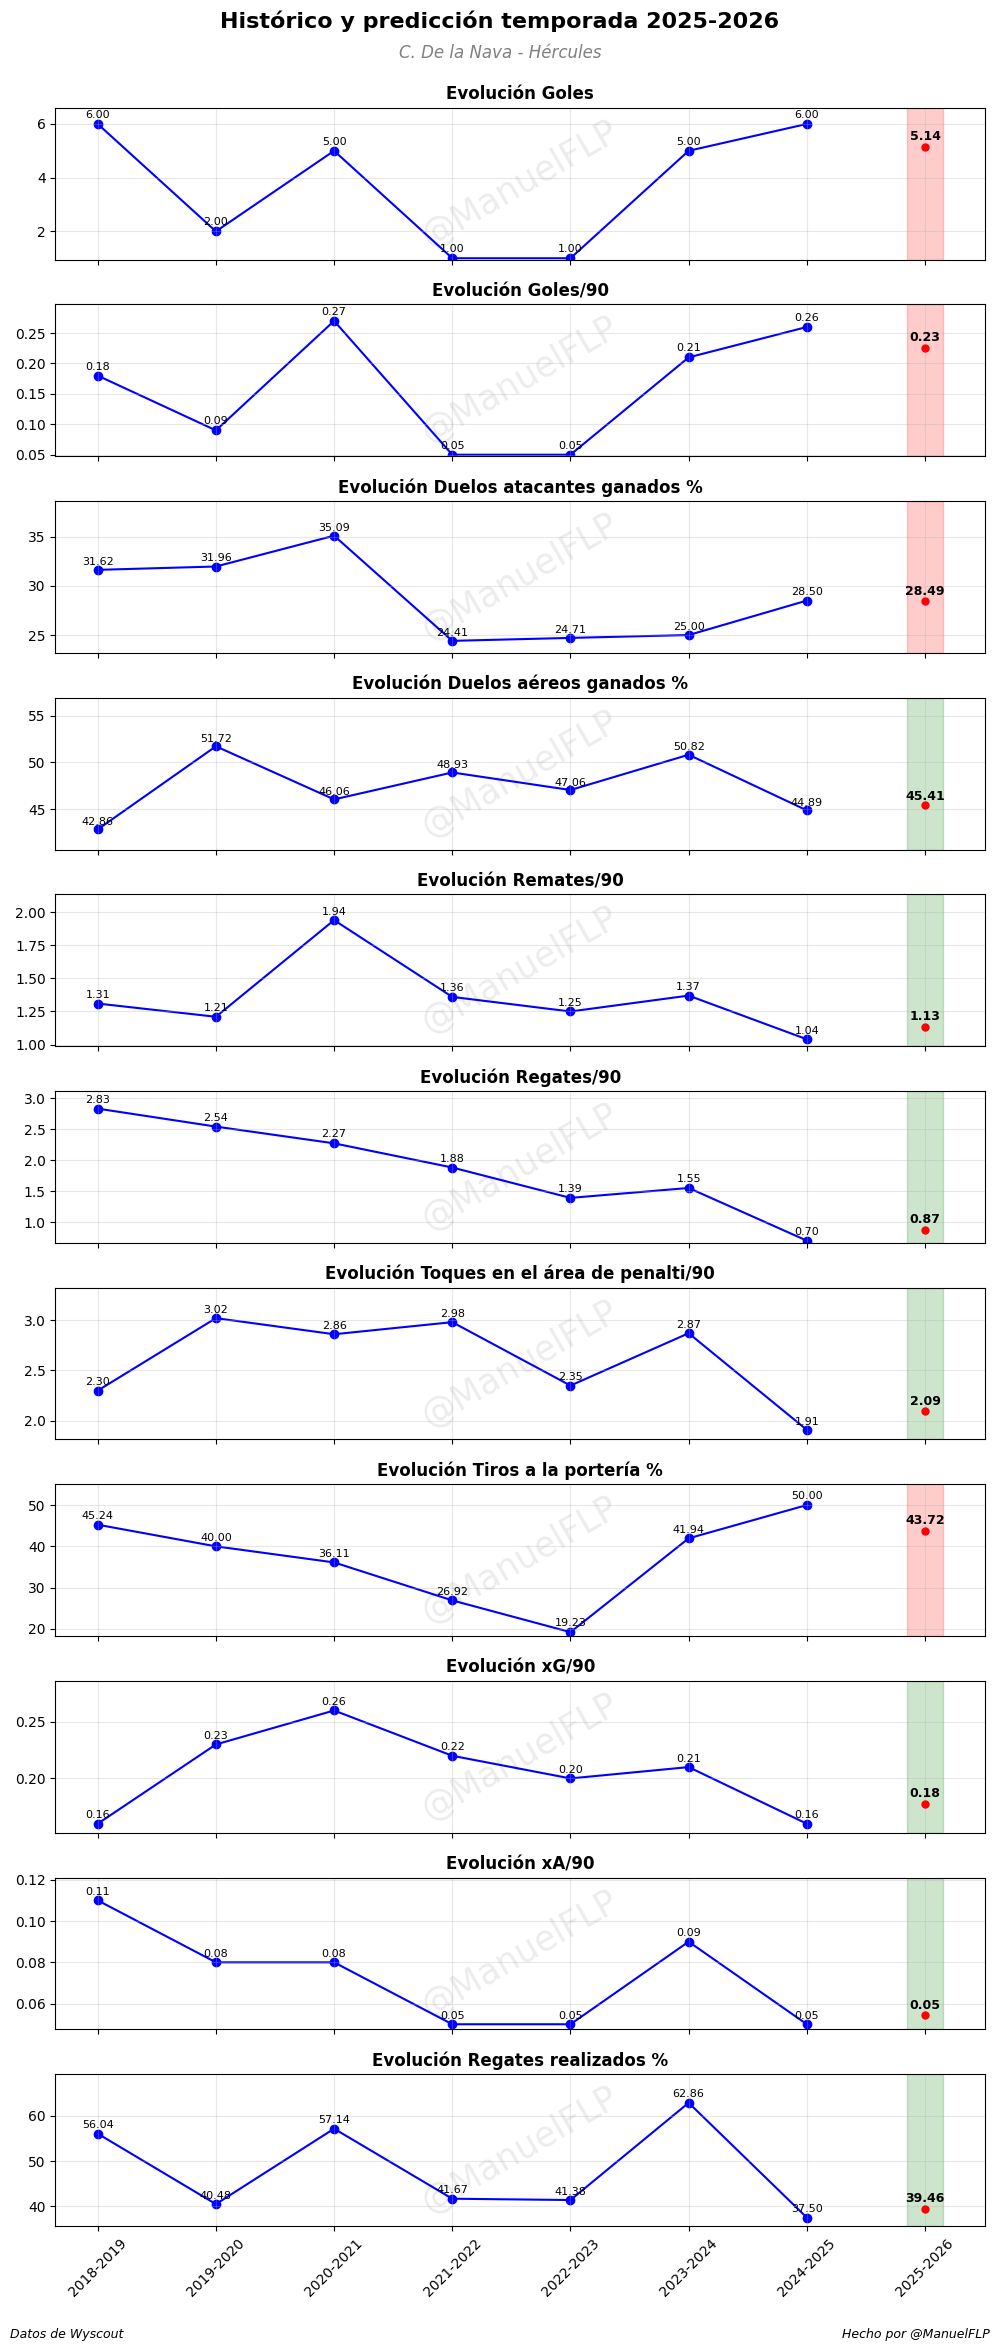

In [38]:
historico = jugador_analizado[jugador_analizado["Temporada"] != temp_pred].reset_index(drop=True)
prediccion = predicciones

df_plot_combined = pd.concat([historico, prediccion], ignore_index=True)

#metrica = ["Goles/90","xG/90", "xA/90", "Tiros a la portería %", "Remates/90"]

fig, axes = plt.subplots(len(metricas), 1, figsize=(10, 24), sharex=True)

# Título y subtítulo generales
fig.suptitle("Histórico y predicción temporada " + temp_pred, fontsize=16, fontweight="bold", y=0.96)
fig.text(0.5, 0.940, nombre_jugador + " - " + equipo_jugador, ha="center", fontsize=12, style="italic", color="gray")

# Posiciones X para histórico y predicción
x_vals = np.arange(len(df_plot_combined))
historico_x = x_vals[:-1]
pred_x = x_vals[-1]

for i, col in enumerate(metricas):
    ax = axes[i]

    # Marca de agua en cada subplot
    ax.text(0.5, 0.5, "@ManuelFLP", transform=ax.transAxes,
            fontsize=25, color='gray', alpha=0.15,
            ha='center', va='center', rotation=30, zorder=0)

    # Línea histórica
    ax.plot(historico_x, historico[col], marker="o", color="blue", label=f"{col} histórico", zorder=1)

    # Valores históricos
    y_range = historico[col].max() - historico[col].min()
    offset = 0.03 * (y_range if y_range > 0 else 1)   # offset dinámico según rango
    for x, y in zip(historico_x, historico[col]):
        ax.text(x, y + offset, f"{y:.2f}", ha="center", va="bottom", fontsize=8, color="black")

    # Valor predicción
    y_pred = prediccion[col].values[0]
    last_real = historico[col].iloc[-1]

    # Color dinámico de la zona predicción
    zona_color = "green" if y_pred > last_real else "red"
    ax.axvspan(pred_x-0.15, pred_x+0.15, color=zona_color, alpha=0.2, zorder=0)

    # Punto predicción
    y_pred = prediccion[col].values[0]
    ax.plot(pred_x, prediccion[col].values[0], marker="o", markersize=5, linestyle="--", color="red",
            label=f"{col} predicción", zorder=2)

    # Valor de predicción
    ax.text(pred_x, y_pred + offset, f"{y_pred:.2f}",
            ha="center", va="bottom", fontsize=9, color="black", fontweight="bold")


    # Ajustes
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)

    # --- Ajuste del eje Y ---
    y_max = max(historico[col].max(), y_pred)     # máximo entre histórico y predicción
    y_min = min(historico[col].min(), y_pred)     # mínimo entre histórico y predicción
    ax.set_ylim(y_min - 0.05*abs(y_min), y_max * 1.1)  # margen arriba y abajo

    ax.set_title(f"Evolución {col}", fontsize=12, fontweight="bold")
    #ax.set_xlabel("Temporada")
    #ax.set_ylabel("Valor")
    ax.grid(alpha=0.3)
    #ax.legend(loc="center left", fontsize=9)

# Eje X con nombres de temporadas
plt.xticks(x_vals, df_plot_combined["Temporada"], rotation=45)
#plt.xlabel("Temporada")

# Créditos: izquierda y derecha
plt.figtext(0.01, -0.01, "Datos de Wyscout", ha="left", fontsize=9, style="italic")
plt.figtext(0.99, -0.01, "Hecho por @ManuelFLP", ha="right", fontsize=9, style="italic")

# Ajustamos rect para dar más espacio al titulo y subtitulo
plt.tight_layout(rect=[0, 0, 1, 0.95])

nom_fich = "Predicción_" + nombre_jugador + "_" + temp_pred + ".png"
plt.savefig(nom_fich, dpi=200 )

plt.show()